In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams["figure.figsize"] = (10,5)

In [76]:
class SalesDataAnalyzer:

    def __init__(self, file_path):
        try:
            self.data = pd.read_csv(file_path)
            print(" Dataset Loaded Successfully!")
            print("Shape:", self.data.shape)

        except Exception as e:
            print("Error:", e)

    def __del__(self):
        print("Program Closed Successfully!")

    def explore_data(self):

        print("\n===== FIRST 5 ROWS =====")
        print(self.data.head())

        print("\n===== LAST 5 ROWS =====")
        print(self.data.tail())

        print("\n===== COLUMN NAMES =====")
        print(self.data.columns)

        print("\n===== DATA TYPES =====")
        print(self.data.dtypes)

        print("\n===== BASIC INFO =====")
        print(self.data.info())

        print("\n===== DESCRIBE =====")
        print(self.data.describe())

    def clean_data(self):

        print("\nMissing Values")
        print(self.data.isnull().sum())

        self.data.drop_duplicates(inplace=True)

        print("\nDuplicates Removed Successfully")

    def numpy_operations(self):

        revenue = self.data["Total Revenue"].to_numpy()

        print("\nNumpy Array Created")

        print("\nIndexing Example")
        print(revenue[0])

        print("\nSlicing Example")
        print(revenue[:10])

        print("\nMathematical Operation")
        print(revenue[:10] * 2)

    def mathematical_operations(self):

        self.data["Profit Margin"] = (
            self.data["Total Profit"] /
            self.data["Total Revenue"]
        ) * 100

        print(
            self.data[
                [
                    "Total Revenue",
                    "Total Profit",
                    "Profit Margin"
                ]
            ].head()
        )

    def combine_data(self):

        first = self.data.head(5)
        last = self.data.tail(5)

        combined = pd.concat([first, last])

        print("\nCombined Data")
        print(combined)

    def split_data(self):

        regions = {}

        for region in self.data["Region"].unique():

            regions[region] = self.data[
                self.data["Region"] == region
            ]

        print("\nData Split Successfully")
        print("Total Regions:", len(regions))

        return regions

    def search_sort_filter(self):

        print("\nTop 10 Profits")

        print(
            self.data.sort_values(
                by="Total Profit",
                ascending=False
            ).head(10)
        )

        print("\nAsia Region Records")

        print(
            self.data[
                self.data["Region"] == "Asia"
            ].head()
        )

    def aggregate_functions(self):

        print("\nTotal Revenue")
        print(self.data["Total Revenue"].sum())

        print("\nAverage Revenue")
        print(self.data["Total Revenue"].mean())

        print("\nAverage Profit")
        print(self.data["Total Profit"].mean())

        print("\nTotal Orders")
        print(self.data["Order ID"].count())

    def statistical_analysis(self):

        print("\nStandard Deviation")
        print(self.data["Total Profit"].std())

        print("\nVariance")
        print(self.data["Total Profit"].var())

        print("\n25 Percentile")
        print(self.data["Total Profit"].quantile(0.25))

        print("\n50 Percentile")
        print(self.data["Total Profit"].quantile(0.50))

        print("\n75 Percentile")
        print(self.data["Total Profit"].quantile(0.75))

    def create_pivot_table(self):

        pivot = pd.pivot_table(
            self.data,
            values="Total Profit",
            index="Region",
            aggfunc=np.sum
        )

        print("\nPivot Table")
        print(pivot)

        return pivot

In [77]:
file_path = "/Users/jayeshdhingra/Downloads/1000 Sales Records.csv"

analyzer = SalesDataAnalyzer(file_path)

 Dataset Loaded Successfully!
Shape: (1000, 14)
Program Closed Successfully


In [78]:
analyzer.explore_data()


===== FIRST 5 ROWS =====
                         Region Country   Item Type Sales Channel  \
0  Middle East and North Africa   Libya   Cosmetics       Offline   
1                 North America  Canada  Vegetables        Online   
2  Middle East and North Africa   Libya   Baby Food       Offline   
3                          Asia   Japan      Cereal       Offline   
4            Sub-Saharan Africa    Chad      Fruits       Offline   

  Order Priority  Order Date   Order ID   Ship Date  Units Sold  Unit Price  \
0              M  10/18/2014  686800706  10/31/2014        8446      437.20   
1              M   11/7/2011  185941302   12/8/2011        3018      154.06   
2              C  10/31/2016  246222341   12/9/2016        1517      255.28   
3              C   4/10/2010  161442649   5/12/2010        3322      205.70   
4              H   8/16/2011  645713555   8/31/2011        9845        9.33   

   Unit Cost  Total Revenue  Total Cost  Total Profit  
0     263.33     3692591.20 

In [79]:
analyzer.clean_data()


Missing Values
Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

Duplicates Removed Successfully


In [80]:
analyzer.numpy_operations()


Numpy Array Created

Indexing Example
3692591.2

Slicing Example
[3692591.2   464953.08  387259.76  683335.4    91853.85 1959909.6
  585010.8   797634.72  374057.68  739488.  ]

Mathematical Operation
[7385182.4   929906.16  774519.52 1366670.8   183707.7  3919819.2
 1170021.6  1595269.44  748115.36 1478976.  ]


In [81]:
analyzer.mathematical_operations()

   Total Revenue  Total Profit  Profit Margin
0     3692591.20    1468506.02      39.768984
1      464953.08     190526.34      40.977541
2      387259.76     145419.62      37.550924
3      683335.40     294295.98      43.067574
4       91853.85      23726.45      25.830654


In [82]:
analyzer.combine_data()


Combined Data
                           Region               Country   Item Type  \
0    Middle East and North Africa                 Libya   Cosmetics   
1                   North America                Canada  Vegetables   
2    Middle East and North Africa                 Libya   Baby Food   
3                            Asia                 Japan      Cereal   
4              Sub-Saharan Africa                  Chad      Fruits   
995  Middle East and North Africa            Azerbaijan      Snacks   
996                        Europe               Georgia   Baby Food   
997  Middle East and North Africa  United Arab Emirates  Vegetables   
998                        Europe               Finland   Household   
999                        Europe              Portugal      Cereal   

    Sales Channel Order Priority  Order Date   Order ID   Ship Date  \
0         Offline              M  10/18/2014  686800706  10/31/2014   
1          Online              M   11/7/2011  185941302   12/

In [83]:
analyzer.split_data()


Data Split Successfully
Total Regions: 7


{'Middle East and North Africa':                            Region               Country        Item Type  \
 0    Middle East and North Africa                 Libya        Cosmetics   
 2    Middle East and North Africa                 Libya        Baby Food   
 22   Middle East and North Africa               Algeria    Personal Care   
 30   Middle East and North Africa               Morocco        Beverages   
 42   Middle East and North Africa                Turkey             Meat   
 ..                            ...                   ...              ...   
 974  Middle East and North Africa                Jordan          Clothes   
 977  Middle East and North Africa               Bahrain        Beverages   
 983  Middle East and North Africa                 Yemen  Office Supplies   
 995  Middle East and North Africa            Azerbaijan           Snacks   
 997  Middle East and North Africa  United Arab Emirates       Vegetables   
 
     Sales Channel Order Priority  Order D

In [84]:
analyzer.search_sort_filter()


Top 10 Profits
                                Region           Country  Item Type  \
904                             Europe           Belgium  Cosmetics   
432                               Asia             India  Cosmetics   
807                             Europe            Sweden  Cosmetics   
612                               Asia          Maldives  Cosmetics   
410       Middle East and North Africa            Turkey  Cosmetics   
456                             Europe          Moldova   Cosmetics   
286                             Europe    Czech Republic  Household   
952              Australia and Oceania  Papua New Guinea  Household   
561  Central America and the Caribbean       Saint Lucia  Cosmetics   
554                               Asia          Mongolia  Household   

    Sales Channel Order Priority  Order Date   Order ID   Ship Date  \
904        Online              H   2/12/2010  403961122   3/20/2010   
432       Offline              L   12/3/2016  653148210   1/

In [85]:
analyzer.aggregate_functions()


Total Revenue
1327321840.33

Average Revenue
1327321.84033

Average Profit
391202.61155999993

Total Orders
1000


In [86]:
analyzer.statistical_analysis()


Standard Deviation
383640.1858646798

Variance
147179792210.28607

25 Percentile
98376.12

50 Percentile
277225.98

75 Percentile
548456.835


In [87]:
analyzer.create_pivot_table()


Pivot Table
                                   Total Profit
Region                                         
Asia                               5.079940e+07
Australia and Oceania              3.187842e+07
Central America and the Caribbean  4.133678e+07
Europe                             1.067720e+08
Middle East and North Africa       5.105699e+07
North America                      7.708059e+06
Sub-Saharan Africa                 1.016510e+08


,Total Profit
Region,
Asia,5.079940e+07
Australia and Oceania,3.187842e+07
Central America and the Caribbean,4.133678e+07
Europe,1.067720e+08
Middle East and North Africa,5.105699e+07
North America,7.708059e+06
Sub-Saharan Africa,1.016510e+08


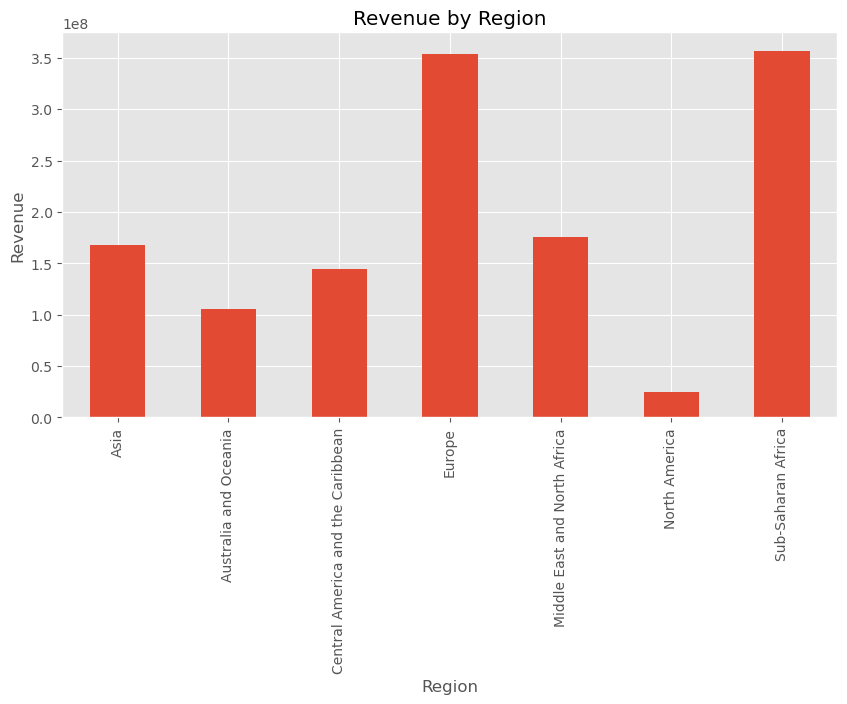

In [88]:
region_revenue = analyzer.data.groupby(
    "Region"
)["Total Revenue"].sum()

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.savefig("bar_plot.png")

plt.show()

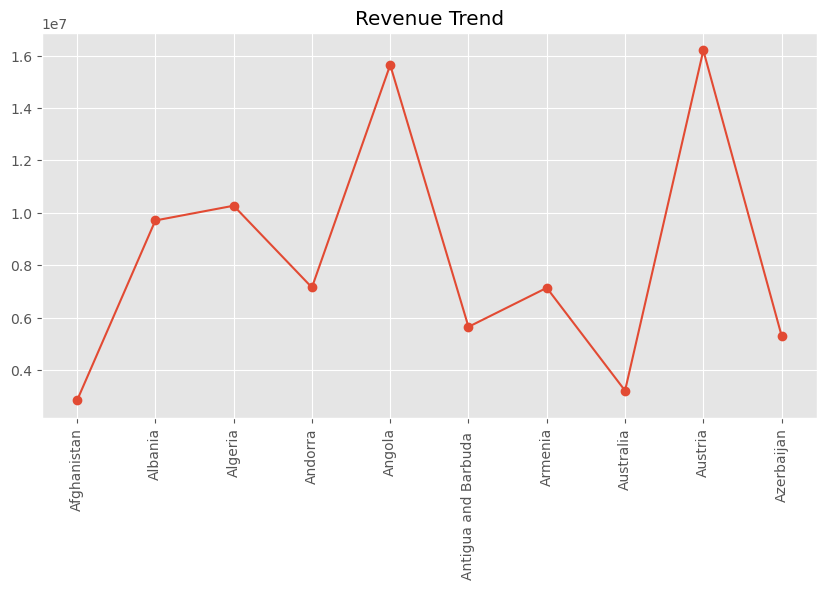

In [89]:
country_sales = analyzer.data.groupby(
    "Country"
)["Total Revenue"].sum().head(10)

plt.plot(
    country_sales.index,
    country_sales.values,
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Revenue Trend")

plt.savefig("line_plot.png")

plt.show()

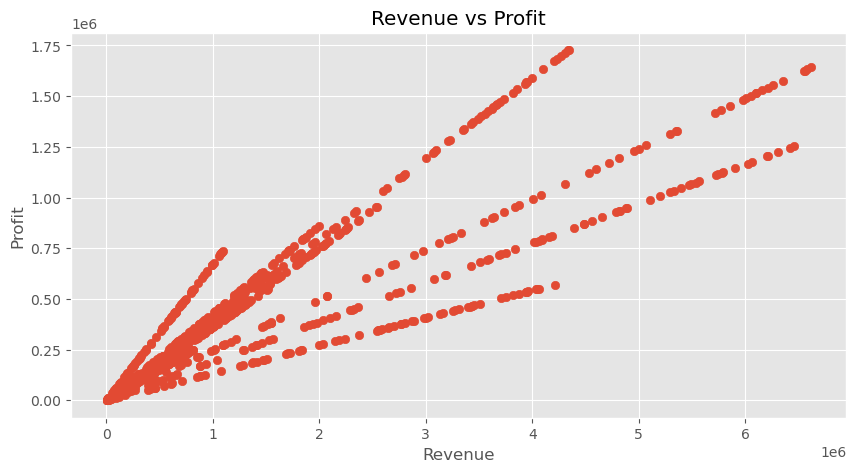

In [90]:
plt.scatter(
    analyzer.data["Total Revenue"],
    analyzer.data["Total Profit"]
)

plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.title("Revenue vs Profit")

plt.savefig("scatter_plot.png")

plt.show()

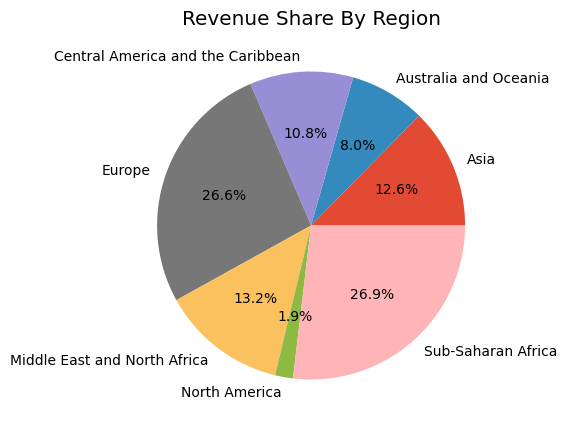

In [91]:
region_sales = analyzer.data.groupby(
    "Region"
)["Total Revenue"].sum()

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Share By Region")

plt.savefig("pie_chart.png")

plt.show()

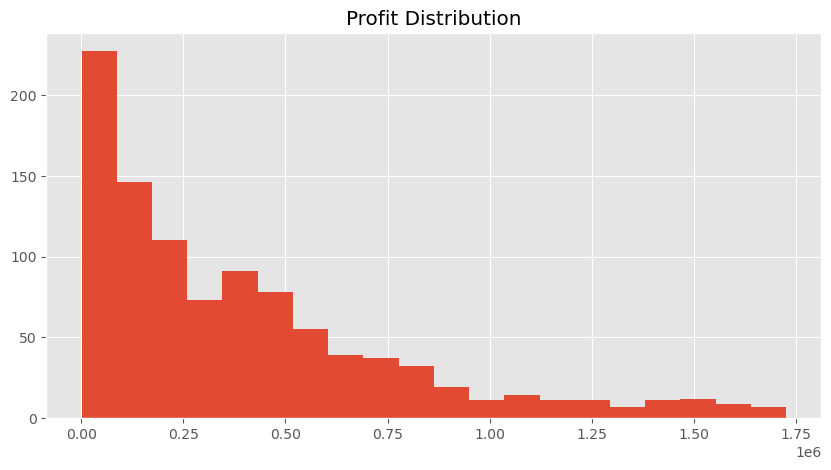

In [92]:
plt.hist(
    analyzer.data["Total Profit"],
    bins=20
)

plt.title("Profit Distribution")

plt.savefig("histogram.png")

plt.show()

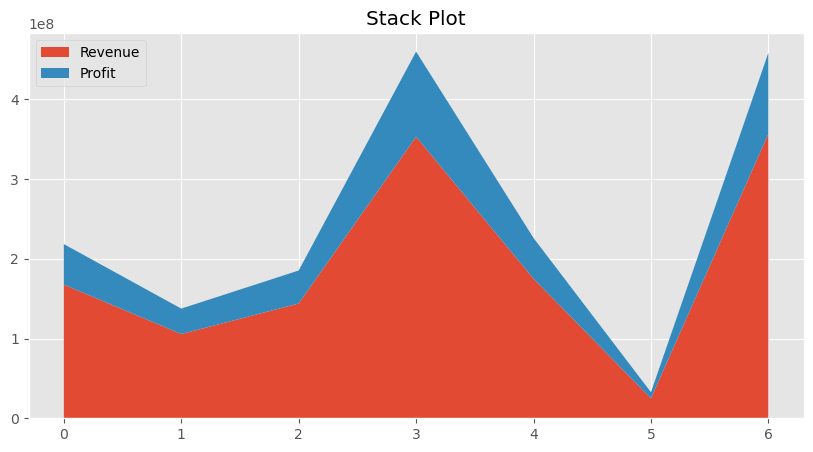

In [93]:
grouped = analyzer.data.groupby(
    "Region"
).agg(
    {
        "Total Revenue":"sum",
        "Total Profit":"sum"
    }
)

x = range(len(grouped))

plt.stackplot(
    x,
    grouped["Total Revenue"],
    grouped["Total Profit"],
    labels=["Revenue","Profit"]
)

plt.legend()

plt.title("Stack Plot")

plt.savefig("stack_plot.png")

plt.show()

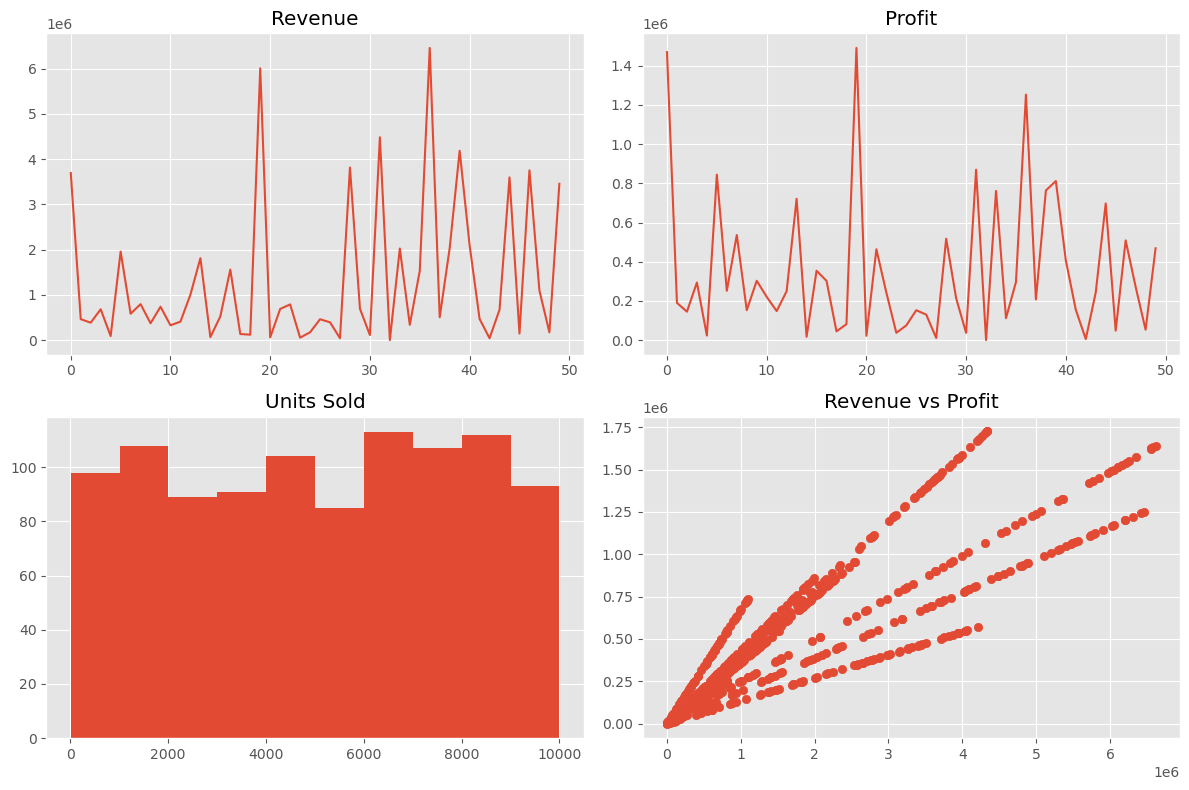

In [94]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

analyzer.data["Total Revenue"].head(50).plot(
    ax=ax[0,0]
)
ax[0,0].set_title("Revenue")

analyzer.data["Total Profit"].head(50).plot(
    ax=ax[0,1]
)
ax[0,1].set_title("Profit")

ax[1,0].hist(
    analyzer.data["Units Sold"]
)
ax[1,0].set_title("Units Sold")

ax[1,1].scatter(
    analyzer.data["Total Revenue"],
    analyzer.data["Total Profit"]
)
ax[1,1].set_title("Revenue vs Profit")

plt.tight_layout()

plt.show()

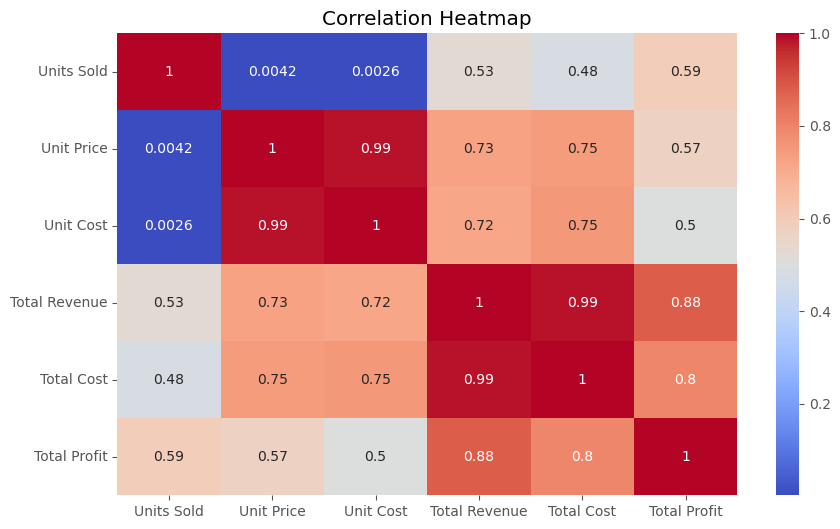

In [95]:
plt.figure(figsize=(10,6))

corr = analyzer.data[
    [
        "Units Sold",
        "Unit Price",
        "Unit Cost",
        "Total Revenue",
        "Total Cost",
        "Total Profit"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("heatmap.png")

plt.show()

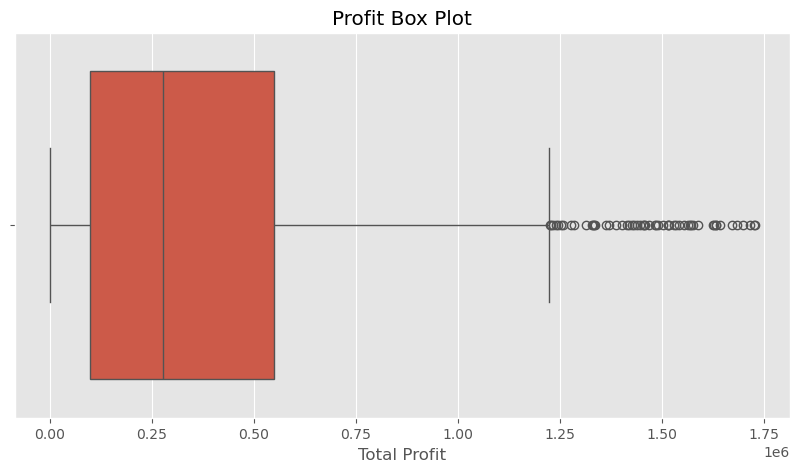

In [96]:
sns.boxplot(
    x=analyzer.data["Total Profit"]
)

plt.title("Profit Box Plot")

plt.savefig("boxplot.png")

plt.show()

In [ ]:
while True:

    print("\n========== DATA ANALYSIS MENU ==========")

    print("1. Explore Data")
    print("2. Clean Data")
    print("3. Numpy Operations")
    print("4. Aggregate Functions")
    print("5. Statistical Analysis")
    print("6. Pivot Table")
    print("7. Exit")

    choice = input("Enter Choice: ")

    if choice == "1":
        analyzer.explore_data()

    elif choice == "2":
        analyzer.clean_data()

    elif choice == "3":
        analyzer.numpy_operations()

    elif choice == "4":
        analyzer.aggregate_functions()

    elif choice == "5":
        analyzer.statistical_analysis()

    elif choice == "6":
        analyzer.create_pivot_table()

    elif choice == "7":
        print("Thank You")
        break

    else:
        print("Invalid Choice")


========== DATA ANALYSIS MENU ==========
1. Explore Data
2. Clean Data
3. Numpy Operations
4. Aggregate Functions
5. Statistical Analysis
6. Pivot Table
7. Exit


Enter Choice:  1



===== FIRST 5 ROWS =====
                         Region Country   Item Type Sales Channel  \
0  Middle East and North Africa   Libya   Cosmetics       Offline   
1                 North America  Canada  Vegetables        Online   
2  Middle East and North Africa   Libya   Baby Food       Offline   
3                          Asia   Japan      Cereal       Offline   
4            Sub-Saharan Africa    Chad      Fruits       Offline   

  Order Priority  Order Date   Order ID   Ship Date  Units Sold  Unit Price  \
0              M  10/18/2014  686800706  10/31/2014        8446      437.20   
1              M   11/7/2011  185941302   12/8/2011        3018      154.06   
2              C  10/31/2016  246222341   12/9/2016        1517      255.28   
3              C   4/10/2010  161442649   5/12/2010        3322      205.70   
4              H   8/16/2011  645713555   8/31/2011        9845        9.33   

   Unit Cost  Total Revenue  Total Cost  Total Profit  Profit Margin  
0     263.33 

Enter Choice:  3



Numpy Array Created

Indexing Example
3692591.2

Slicing Example
[3692591.2   464953.08  387259.76  683335.4    91853.85 1959909.6
  585010.8   797634.72  374057.68  739488.  ]

Mathematical Operation
[7385182.4   929906.16  774519.52 1366670.8   183707.7  3919819.2
 1170021.6  1595269.44  748115.36 1478976.  ]

========== DATA ANALYSIS MENU ==========
1. Explore Data
2. Clean Data
3. Numpy Operations
4. Aggregate Functions
5. Statistical Analysis
6. Pivot Table
7. Exit


Enter Choice:  5



Standard Deviation
383640.1858646798

Variance
147179792210.28607

25 Percentile
98376.12

50 Percentile
277225.98

75 Percentile
548456.835

========== DATA ANALYSIS MENU ==========
1. Explore Data
2. Clean Data
3. Numpy Operations
4. Aggregate Functions
5. Statistical Analysis
6. Pivot Table
7. Exit


Enter Choice:  6



Pivot Table
                                   Total Profit
Region                                         
Asia                               5.079940e+07
Australia and Oceania              3.187842e+07
Central America and the Caribbean  4.133678e+07
Europe                             1.067720e+08
Middle East and North Africa       5.105699e+07
North America                      7.708059e+06
Sub-Saharan Africa                 1.016510e+08

========== DATA ANALYSIS MENU ==========
1. Explore Data
2. Clean Data
3. Numpy Operations
4. Aggregate Functions
5. Statistical Analysis
6. Pivot Table
7. Exit
